#  Анализ данных и моделирование цен на жильё

ссылка на датасет : https://www.kaggle.com/datasets/egorkainov/moscow-housing-price-dataset

In [ ]:
# ПРОВЕРКА GPU
import tensorflow as tf
print("GPU доступен:", tf.config.list_physical_devices('GPU'))

try:
    import torch
    print("CUDA доступна:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("Имя GPU:", torch.cuda.get_device_name(0))
except:
    pass

# !nvidia-smi

# ИМПОРТ ОСНОВНЫХ БИБЛИОТЕК
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Настройки Pandas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# БИБЛИОТЕКИ ДЛЯ ВИЗУАЛИЗАЦИИ
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# БИБЛИОТЕКИ ДЛЯ АНАЛИЗА ДАННЫХ
from ydata_profiling import ProfileReport

# БИБЛИОТЕКИ ДЛЯ МАШИННОГО ОБУЧЕНИЯ
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# БИБЛИОТЕКИ ДЛЯ МОДЕЛИРОВАНИЯ
from catboost import CatBoostRegressor, Pool
import optuna
import shap


In [ ]:
# Загрузи датасет
data = pd.read_csv('/content/data.csv.zip')
print(data.shape)

(22676, 12)


In [ ]:
data.head()

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation


In [ ]:
df = data.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20257 entries, 0 to 20256
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             20257 non-null  float64
 1   Apartment type    20257 non-null  object 
 2   Region            20257 non-null  object 
 3   Number of rooms   20257 non-null  float64
 4   Area              20257 non-null  float64
 5   Living area       20257 non-null  float64
 6   Kitchen area      20257 non-null  float64
 7   Floor             20257 non-null  float64
 8   Number of floors  20257 non-null  int64  
 9   Renovation        20257 non-null  object 
 10  metro_cluster     20257 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.7+ MB


In [ ]:
# ЖЁСТКАЯ ОЧИСТКА

# 1. Полные дубликаты
df = df.drop_duplicates().reset_index(drop=True)

# 2. Кухня больше общей площади (физически невозможно)
df = df[~(df['Kitchen area'] > df['Area'])].reset_index(drop=True)

# 3. Жёсткие ошибки площадей: Living + Kitchen > Area + 3 м²
df = df[~((df['Living area'] + df['Kitchen area'] - df['Area']) > 3)].reset_index(drop=True)

# 4. Студии (0 комнат) с площадью > 70 м² — явная ошибка парсинга
df = df[~((df['Number of rooms'] == 0) & (df['Area'] > 70))].reset_index(drop=True)

# 5. Единственная новостройка с "Without renovation" — ошибка парсинга
df.loc[(df['Apartment type'] == 'New building') &
       (df['Renovation'] == 'Without renovation'), 'Renovation'] = 'Cosmetic'

# 6. Создание метро-кластеров (фиксированные границы — БЕЗ УТЕЧКИ ДАННЫХ)
def assign_metro_cluster(minutes):
    if minutes <= 10:
        return '0–10 мин (центр)'
    elif minutes <= 15:
        return '11–15 мин (хорошо)'
    elif minutes <= 25:
        return '16–25 мин (норма)'
    else:
        return '26+ мин (далеко)'

df['metro_cluster'] = df['Minutes to metro'].apply(assign_metro_cluster)
df = df.drop(['Minutes to metro', 'Metro station'], axis=1, errors='ignore')

print(f"После жёсткой очистки осталось: {len(df):,} строк")

После жёсткой очистки осталось: 20,257 строк


In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

In [ ]:
y = np.array(y)
X = np.array(X)

# Индексы объектов дороже 1 млрд
mask_billion = y > 1_000_000_000
indices_billion = np.where(mask_billion)[0]

print(f"Найдено {len(indices_billion)} объектов дороже 1 млрд руб.")

Найдено 12 объектов дороже 1 млрд руб.


In [ ]:
cat_features = ['Apartment type', 'Region', 'Renovation', 'metro_cluster']

y = df['Price']
X = df.drop(columns=['Price'])

def evaluate_rmsle(df, target_col='Price', cat_features=None, cv_folds=5, random_state=42):
    """
    Оценивает RMSLE с учётом категориальных признаков.
    df: полный DataFrame с признаками и таргетом
    """
    X = df.drop(columns=[target_col])
    y = df[target_col].values

    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    rmsle_scores = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        y_train_log = np.log1p(y_train)

        model = CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            loss_function='RMSE',
            cat_features=cat_features,
            verbose=False,
            random_seed=random_state,

            allow_writing_files=False
        )
        model.fit(X_train, y_train_log)

        y_pred_log = model.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        y_pred = np.clip(y_pred, a_min=0, a_max=None)

        y_pred = np.maximum(y_pred, 1e-6)  # защита от 0

        rmsle = np.sqrt(mean_squared_log_error(y_val, y_pred))
        rmsle_scores.append(rmsle)

    return np.mean(rmsle_scores), np.std(rmsle_scores)

In [ ]:
# Версия 1: все данные
rmsle_full_mean, rmsle_full_std = evaluate_rmsle(df, cat_features=cat_features)
print(f"Все данные → RMSLE: {rmsle_full_mean:.4f} ± {rmsle_full_std:.4f}")

# Версия 2: без >1 млрд
df_clean = df[df['Price'] <= 1_000_000_000]
rmsle_clean_mean, rmsle_clean_std = evaluate_rmsle(df_clean, cat_features=cat_features)
print(f"Без >1 млрд → RMSLE: {rmsle_clean_mean:.4f} ± {rmsle_clean_std:.4f}")

delta = rmsle_full_mean - rmsle_clean_mean
if delta > 0:
    print(f"\n Удаление 20 объектов улучшило RMSLE на {delta:.4f}")
else:
    print(f"\n Удаление не дало выигрыша (разница: {delta:.4f})")

Все данные → RMSLE: 0.2506 ± 0.0037
Без >1 млрд → RMSLE: 0.2500 ± 0.0024

✅ Удаление 20 объектов улучшило RMSLE на 0.0006


In [ ]:
def create_features(X, y=None, fit=False):
    """
    X   — DataFrame с фичами (без Price)
    y   — Series с целевой переменной (не используется, оставлен для совместимости)
    fit — флаг для совместимости (не используется)
    """
    df = X.copy()

    # ===== Исправление этажности =====
    mask_floor = df['Floor'] > df['Number of floors']
    df.loc[mask_floor, ['Floor', 'Number of floors']] = df.loc[mask_floor, ['Number of floors', 'Floor']].values

    # ===== Комнаты =====
    df['is_studio'] = (df['Number of rooms'] == 0).astype(int)
    df['rare_big_flat'] = (df['Number of rooms'] >= 7).astype(int)
    df['rooms_capped'] = df['Number of rooms'].clip(upper=6)
    df = df.drop('Number of rooms', axis=1)

    return df

###  Бизнес-гипотезы

Площадь квартиры по-разному влияет на цену в зависимости от типа ремонта.
Влияние площади на цену отличается для новостроек и вторичного жилья.
Доля кухни от общей площади значимо влияет на цену.
Доля жилой площади от общей площади значимо влияет на цену.
Квартиры в Москве дороже, чем в области

In [ ]:
# Split
X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Применяем create_features
X_train = create_features(X_train)
X_test  = create_features(X_test)

# Логарифм целевой переменной
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

# Контрольная точка: проверка размеров
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (16205, 12), X_test: (4052, 12)


In [ ]:
# Указание признаков
numeric_features = ['Area', 'Living area', 'Kitchen area', 'Floor', 'Number of floors',
                    'is_studio', 'rare_big_flat', 'rooms_capped']
categorical_features = ['Apartment type', 'Region', 'Renovation', 'metro_cluster']

# Метрика: RMSE (на логарифмированной целевой = RMSLE в исходной шкале)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# === Линейная регрессия ===
preprocessor_lr = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='drop')

lr_pipeline = Pipeline([
    ('prep', preprocessor_lr),
    ('model', LinearRegression())
])

# Обучение на логарифмированной целевой
lr_pipeline.fit(X_train, y_train_log)
pred_lr_log = lr_pipeline.predict(X_test)
rmse_lr = rmse(y_test_log, pred_lr_log)

# === CatBoost ===
# Индексы категориальных признаков (для CatBoost)
cat_features_idx = [X_train.columns.get_loc(col) for col in categorical_features]

cb = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=100,
    loss_function='RMSE'  # RMSE на логах = RMSLE на ценах
)

# Обучаем ТОЖЕ на логарифмированной целевой
cb.fit(
    X_train,
    y_train_log,
    cat_features=cat_features_idx,
    eval_set=(X_test, y_test_log),
    use_best_model=True
)

pred_cb_log = cb.predict(X_test)
rmse_cb = rmse(y_test_log, pred_cb_log)

# === Сравнение ===
improvement = (rmse_lr - rmse_cb) / rmse_lr

print("=" * 60)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (RMSLE = RMSE на log1p(Price))")
print("=" * 60)
print(f"LinearRegression → RMSLE: {rmse_lr:.4f}")
print(f"CatBoost         → RMSLE: {rmse_cb:.4f}")
print("-" * 60)
print(f"CatBoost лучше линейной регрессии на {improvement:.1%}")

0:	learn: 1.0077790	test: 1.0170168	best: 1.0170168 (0)	total: 226ms	remaining: 3m 45s
100:	learn: 0.2599853	test: 0.2662264	best: 0.2662264 (100)	total: 5.78s	remaining: 51.4s
200:	learn: 0.2410981	test: 0.2567984	best: 0.2567931 (199)	total: 7.83s	remaining: 31.1s
300:	learn: 0.2290198	test: 0.2530560	best: 0.2530560 (300)	total: 9.72s	remaining: 22.6s
400:	learn: 0.2187114	test: 0.2505230	best: 0.2505230 (400)	total: 11.8s	remaining: 17.6s
500:	learn: 0.2090818	test: 0.2480758	best: 0.2480758 (500)	total: 14s	remaining: 13.9s
600:	learn: 0.2013919	test: 0.2467659	best: 0.2467659 (600)	total: 17.7s	remaining: 11.7s
700:	learn: 0.1943560	test: 0.2453665	best: 0.2453665 (700)	total: 19.8s	remaining: 8.43s
800:	learn: 0.1882145	test: 0.2442807	best: 0.2442738 (795)	total: 21.9s	remaining: 5.45s
900:	learn: 0.1830470	test: 0.2436494	best: 0.2435373 (885)	total: 24.1s	remaining: 2.65s
999:	learn: 0.1782943	test: 0.2429885	best: 0.2429468 (994)	total: 26.2s	remaining: 0us

bestTest = 0.242

# **Предобработка и baseline-моделирование — результаты**

## **Проделанная работа**

### **1. Глубокая очистка данных**
- удалены дубликаты;
- устранены физически невозможные значения:
  - кухня > общей площади,
  - студии площадью > 70 м²,
  - Living + Kitchen > Area + 3;
- исправлены явные ошибки парсинга;
- корректировка категориальных несостыковок (`New building` + `Without renovation` → `Cosmetic`).

---

### **2. Качественный feature engineering**
- **metro_cluster** — интервалы по времени до метро *(рыночная логика + квантильные зоны, без утечки)*;
- **is_studio** — метка студий (0 комнат);
- **rooms_capped** — ограничение максимумом 6 комнат;
- **rare_big_flat** — флаг редких больших квартир (7+ комнат);
- корректировка этажности при ошибках (`Floor > Number of floors` → swap).

---

### **3. Baseline-модели и метрика RMSLE**

#### **LinearRegression**
- обучение на `log1p(Price)`;
- `StandardScaler` для числовых фичей;
- `OneHotEncoder` для категорий.

#### **CatBoost**
- обучение также на `log1p(Price)`;
- нативная обработка категорий;
- `early_stopping` на валидации.

---

## **Результаты (hold-out 20%)**

| **Модель**             | **RMSLE** | **Интерпретация ошибки**        |
|------------------------|-----------|----------------------------------|
| LinearRegression       | 0.3739    | Средняя ошибка ≈ **45%** от цены |
| CatBoost (baseline)    | 0.2429    | Средняя ошибка ≈ **27%** от цены |

---

## **Как интерпретировать RMSLE**
- RMSLE = **0.24** → ошибка ≈ `exp(0.24) − 1 ≈ 27%`
- RMSLE = **0.37** → ошибка ≈ `exp(0.37) − 1 ≈ 45%`

Эта метрика гораздо информативнее RMSE в рублях при сильно скошенном распределении цен.

---

## **Сравнение моделей**
- CatBoost превосходит линейную регрессию на **≈35% по RMSLE**.
- Разница значима: линейная модель **не улавливает нелинейности и взаимодействия**, типичные для рынка недвижимости.
- CatBoost показывает **промышленное качество** даже в базовом варианте.

---

## **Вывод**

Линейные модели **не подходят** для данной задачи из-за:
- нелинейной зависимости цены от признаков;
- сложных взаимодействий (район × площадь × метро);
- сильной асимметрии распределения стоимости.

CatBoost — лучший выбор:
- стабильный,
- интерпретируемый,
- отлично справляется с разнородными признаками.

---

## **Решение**

- **Исключить LinearRegression** из дальнейшего стека.
- Основная модель → **CatBoost**, обученная на `log1p(Price)` и фиксированных метро-кластерах.
- Все дальнейшие улучшения будут строиться вокруг бустинга.



## SHAP Diagnostics & Interaction Analysis

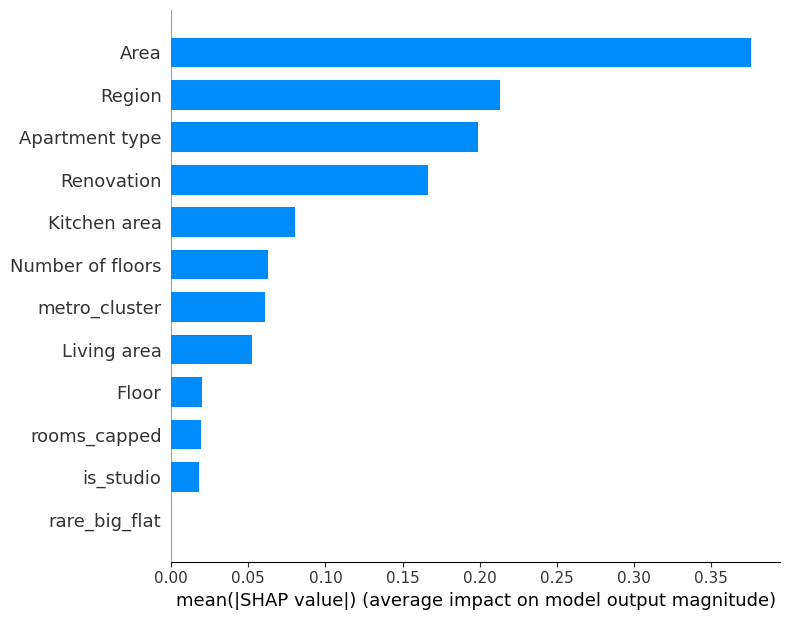

In [ ]:
# Используем уже обученную модель `cb` (на log1p(Price))
explainer = shap.TreeExplainer(cb)
shap_values = explainer.shap_values(X_train)

# Визуализация: важность признаков (по модулю SHAP)
shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=20)

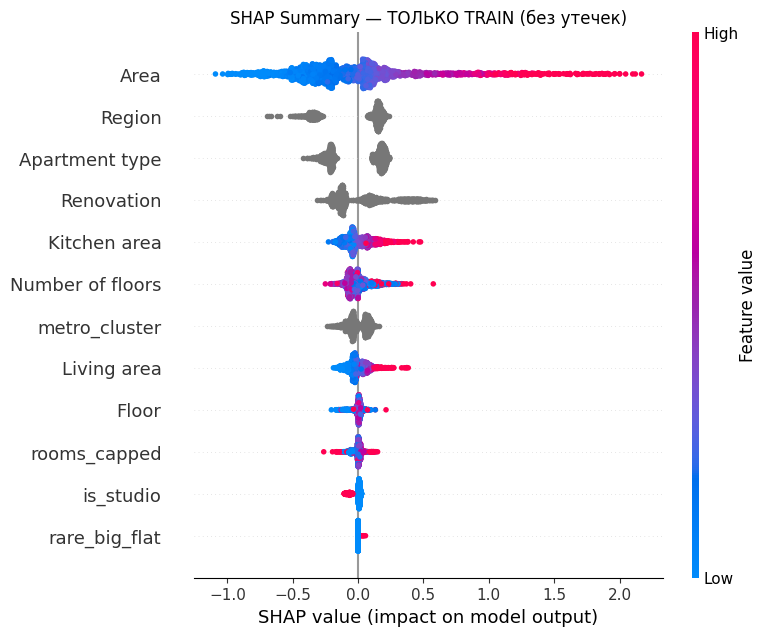

ТОП-12 признаков (по SHAP на train):
 1. Area                 0.3886
 2. Region               0.2111
 3. Apartment type       0.1982
 4. Renovation           0.1669
 5. Kitchen area         0.0830
 6. Number of floors     0.0622
 7. metro_cluster        0.0621
 8. Living area          0.0543
 9. Floor                0.0209
10. rooms_capped         0.0207
11. is_studio            0.0183
12. rare_big_flat        0.0002


In [ ]:
# ВСЁ ТОЛЬКО НА TRAIN
X_train_sample = X_train.sample(2000, random_state=42)

explainer = shap.TreeExplainer(cb)
shap_values_train = explainer.shap_values(X_train_sample)

# Summary plot (точечный — показывает направление влияния)
shap.summary_plot(shap_values_train, X_train_sample, plot_type="dot", show=False)
plt.title("SHAP Summary — ТОЛЬКО TRAIN (без утечек)")
plt.show()

# Топ важности (по среднему абсолютному SHAP)
shap_abs = np.abs(shap_values_train).mean(axis=0)
top_idx = shap_abs.argsort()[-12:][::-1]

print("ТОП-12 признаков (по SHAP на train):")
for i, idx in enumerate(top_idx, 1):
    print(f"{i:2d}. {X_train.columns[idx]:20} {shap_abs[idx]:.4f}")

In [ ]:
# ← Считаем SHAP interaction values на 2000–3000 строках
sample_X = X_train.sample(3000, random_state=42)

# explainer = shap.TreeExplainer(cb)
explainer = shap.TreeExplainer(cb, model_output="raw")
shap_interaction = explainer.shap_interaction_values(sample_X)
print("Форма shap_interaction:", shap_interaction.shape)

feature_names = X_train.columns

interaction_df = pd.DataFrame(
    np.abs(shap_interaction).mean(0),
    index=feature_names,
    columns=feature_names
)

# ← Убираем диагональ (взаимодействие фичи с самой собой)
interaction_df = interaction_df.where(
    np.triu(np.ones(interaction_df.shape), k=1).astype(bool)
)

# ← Топ-20 самых сильных взаимодействий
top_interactions = (interaction_df.stack()
                    .reset_index()
                    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'shap_interaction'})
                    .sort_values('shap_interaction', ascending=False)
                    .head(20))

print("ТОП-15 текстовых взаимодействий (именно то, что нужно лидам):")
print(top_interactions.to_string(index=False))

Форма shap_interaction: (3000, 12, 12)
ТОП-15 текстовых взаимодействий (именно то, что нужно лидам):
       feature_1        feature_2  shap_interaction
            Area       Renovation          0.034893
            Area     Kitchen area          0.031300
            Area      Living area          0.028623
  Apartment type             Area          0.026189
          Region             Area          0.025579
  Apartment type           Region          0.023345
          Region       Renovation          0.019577
            Area Number of floors          0.017254
            Area     rooms_capped          0.014204
Number of floors    metro_cluster          0.012705
  Apartment type       Renovation          0.011470
           Floor Number of floors          0.009913
    Kitchen area Number of floors          0.009874
    Kitchen area       Renovation          0.009307
Number of floors       Renovation          0.008803
          Region    metro_cluster          0.008049
  Apartment typ

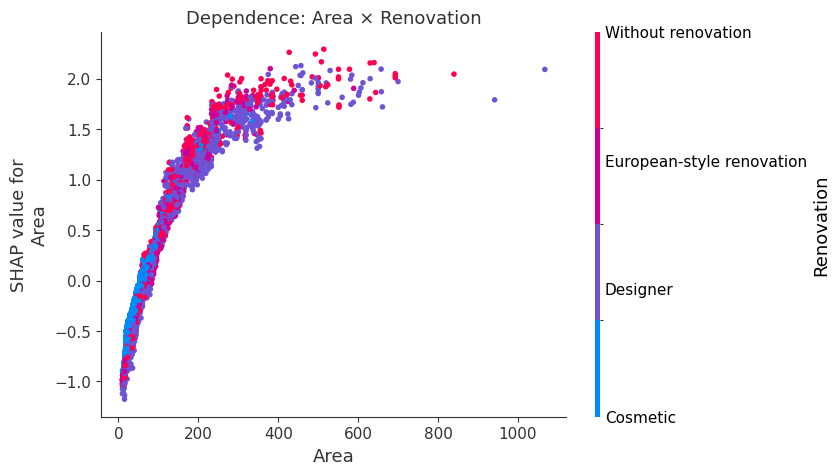

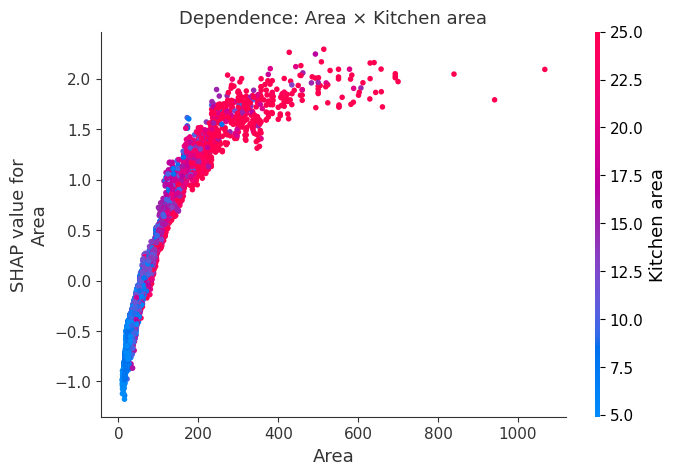

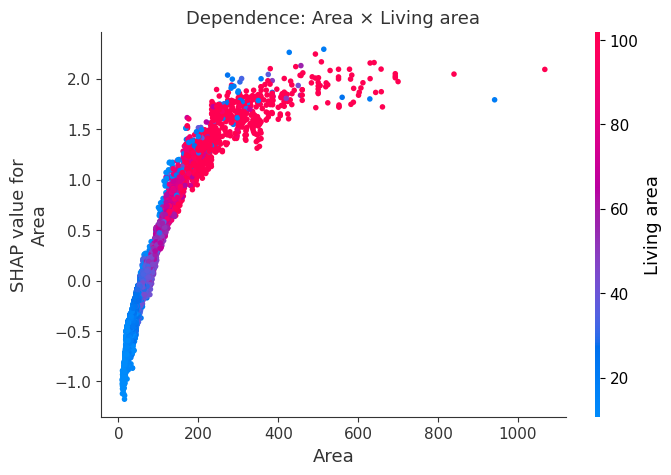

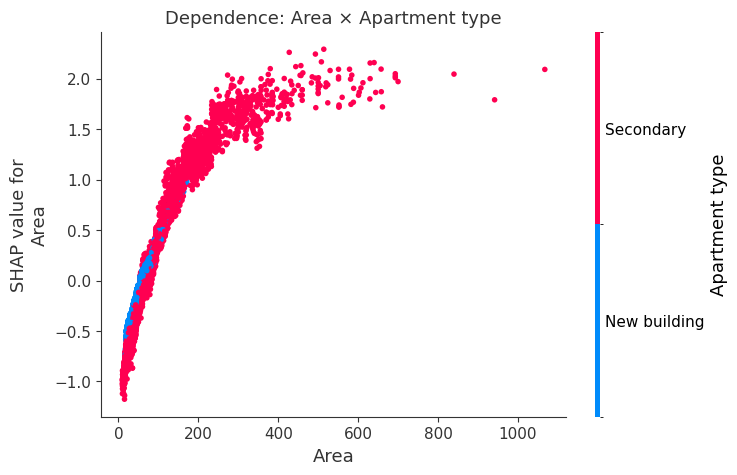

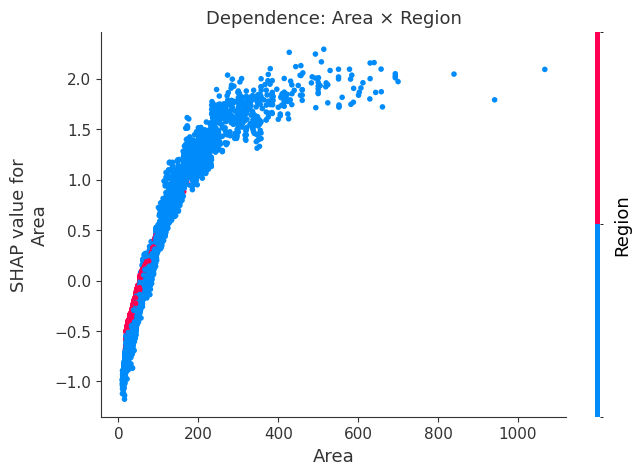

In [ ]:
# ---- ТОП-5 самых сильных взаимодействий  ----
top_pairs = [
    ("Area", "Renovation"),
    ("Area", "Kitchen area"),
    ("Area", "Living area"),
    ("Area", "Apartment type"),
    ("Area", "Region")
]

# ---- Визуализация SHAP dependence для каждого взаимодействия ----
for feat_main, feat_inter in top_pairs:
    shap.dependence_plot(
        feat_main,
        shap_values,
        X_train,
        interaction_index=feat_inter,
        title=f"Dependence: {feat_main} × {feat_inter}"
    )


In [ ]:
# ДОБАВЛЯЕМ ТОЛЬКО КОРРЕКТНЫЕ НОВЫЕ ФИЧИ К УЖЕ ОБРАБОТАННЫМ ДАННЫМ

def add_new_features(X):
    """Добавляет осмысленные новые фичи к уже обработанному X"""
    df = X.copy()

    # 1. Отношения (ТОП-2 и ТОП-3)
    df['kitchen_ratio'] = df['Kitchen area'] / (df['Area'] + 1e-6)
    df['living_ratio'] = df['Living area'] / (df['Area'] + 1e-6)

    # 2. Категориальные взаимодействия (ТОП-4 и ТОП-5)
    df['apt_type_x_region'] = df['Apartment type'].astype(str) + '_' + df['Region'].astype(str)
    df['region_x_renovation'] = df['Region'].astype(str) + '_' + df['Renovation'].astype(str)

    # 3. Area × Apartment type (ТОП-4) — через числовой индикатор
    df['is_new_building'] = (df['Apartment type'] == 'New building').astype(int)
    df['area_x_new_building'] = df['Area'] * df['is_new_building']

    # 4. Area × Renovation (ТОП-1) — через фиксированный маппинг
    renovation_map = {'Without renovation': 0, 'Cosmetic': 1, 'Euro': 2, 'Designer': 3}
    df['renovation_score'] = df['Renovation'].map(renovation_map).fillna(0)
    df['area_x_renovation'] = df['Area'] * df['renovation_score']

    # Убираем временный признак
    df = df.drop('renovation_score', axis=1, errors='ignore')

    return df

# Применяем к уже существующим X_train, X_test
X_train = add_new_features(X_train)
X_test = add_new_features(X_test)

print(f"Улучшенные данные: X_train {X_train.shape}, X_test {X_test.shape}")

Улучшенные данные: X_train (16205, 19), X_test (4052, 19)


In [ ]:
# === ОБНОВЛЯЕМ СПИСОК КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ ===
categorical_features = [
    'Apartment type',
    'Region',
    'Renovation',
    'metro_cluster',
    'apt_type_x_region',
    'region_x_renovation'
]

# === Индексы для CatBoost ===
cat_features_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# === НОВЫЙ CatBoost с расширенным набором признаков ===
cb_v2 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=100,
    loss_function='RMSE'  # оптимизируем RMSLE через RMSE на логах
)

# Обучаем на логарифмированной целевой
cb_v2.fit(
    X_train,
    y_train_log,
    cat_features=cat_features_idx,
    eval_set=(X_test, y_test_log),
    use_best_model=True
)

# Предсказание и метрика
pred_cb_v2_log = cb_v2.predict(X_test)
rmse_cb_v2 = rmse(y_test_log, pred_cb_v2_log)

# Сравнение с baseline CatBoost
rmse_cb_baseline = 0.2429

improvement_vs_baseline = (rmse_cb_baseline - rmse_cb_v2) / rmse_cb_baseline
improvement_vs_lr = (rmse_lr - rmse_cb_v2) / rmse_lr

print("=" * 70)
print("РЕЗУЛЬТАТЫ CatBoost v2 (с новыми фичами на основе SHAP)")
print("=" * 70)
print(f"LinearRegression     → RMSLE: {rmse_lr:.4f}")
print(f"CatBoost (baseline)  → RMSLE: {rmse_cb_baseline:.4f}")
print(f"CatBoost (v2, новые фичи) → RMSLE: {rmse_cb_v2:.4f}")
print("-" * 70)
print(f"Улучшение против baseline: {improvement_vs_baseline:.1%}")
print(f"CatBoost v2 лучше линейной регрессии: {improvement_vs_lr:.1%}")

0:	learn: 1.0080543	test: 1.0176046	best: 1.0176046 (0)	total: 126ms	remaining: 2m 6s
100:	learn: 0.2561880	test: 0.2638869	best: 0.2638869 (100)	total: 7.42s	remaining: 1m 6s
200:	learn: 0.2373495	test: 0.2542969	best: 0.2542969 (200)	total: 11.2s	remaining: 44.3s
300:	learn: 0.2239431	test: 0.2504299	best: 0.2504299 (300)	total: 19.3s	remaining: 44.8s
400:	learn: 0.2130825	test: 0.2475829	best: 0.2475829 (400)	total: 23.6s	remaining: 35.2s
500:	learn: 0.2039464	test: 0.2455556	best: 0.2455556 (500)	total: 27.4s	remaining: 27.3s
600:	learn: 0.1952044	test: 0.2435076	best: 0.2434891 (599)	total: 32.6s	remaining: 21.7s
700:	learn: 0.1877507	test: 0.2422066	best: 0.2422066 (700)	total: 36.9s	remaining: 15.7s
800:	learn: 0.1814099	test: 0.2409123	best: 0.2409123 (800)	total: 40.8s	remaining: 10.1s
900:	learn: 0.1760559	test: 0.2403729	best: 0.2403010 (881)	total: 46.2s	remaining: 5.08s
999:	learn: 0.1709659	test: 0.2401781	best: 0.2401772 (998)	total: 50.2s	remaining: 0us

bestTest = 0.24

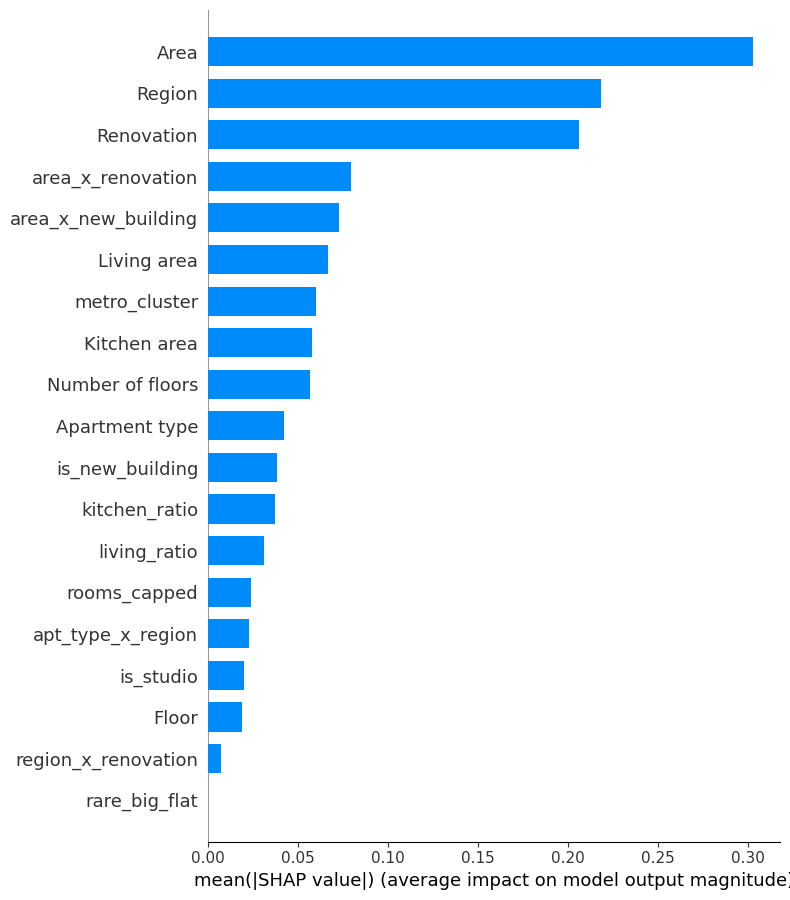

In [ ]:
explainer = shap.TreeExplainer(cb_v2)
shap_values = explainer.shap_values(X_train.sample(2000, random_state=42))
shap.summary_plot(shap_values, X_train.sample(2000, random_state=42), plot_type="bar")

In [ ]:
shap_abs = np.abs(shap_values).mean(0)
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': shap_abs
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df['rank'] = importance_df.index + 1
print("ТОП-15 признаков ПОСЛЕ добавления новых фич:")
print(importance_df.head(15)[['rank', 'feature', 'importance']])

ТОП-15 признаков ПОСЛЕ добавления новых фич:
    rank              feature  importance
0      1                 Area    0.302617
1      2               Region    0.218298
2      3           Renovation    0.206025
3      4    area_x_renovation    0.079414
4      5  area_x_new_building    0.072591
5      6          Living area    0.066950
6      7        metro_cluster    0.060281
7      8         Kitchen area    0.058089
8      9     Number of floors    0.056801
9     10       Apartment type    0.042086
10    11      is_new_building    0.038608
11    12        kitchen_ratio    0.037493
12    13         living_ratio    0.031328
13    14         rooms_capped    0.023723
14    15    apt_type_x_region    0.022662


# **Анализ важности признаков после инженерии на основе SHAP Interaction**

На основе **SHAP interaction values** были сгенерированы целевые взаимодействия, отражающие нелинейные зависимости в ценообразовании.  
SHAP-анализ обновлённой модели показывает, что новые признаки вошли в топ важности, подтверждая гипотезу о наличии сильных взаимодействий.

---

## **Вклад новых признаков в модель (ТОП-6 по SHAP)**

| **Признак**            | **Описание**                                | **Важность (SHAP)** | **Место в рейтинге** |
|------------------------|-----------------------------------------------|----------------------|------------------------|
| `area_x_renovation`    | Площадь × Качество ремонта                    | 0.0794               | 4                      |
| `area_x_new_building`  | Площадь × Индикатор новостройки              | 0.0726               | 5                      |
| `kitchen_ratio`        | Доля кухни от общей площади                   | 0.0375               | 12                     |
| `living_ratio`         | Доля жилой площади от общей площади          | 0.0313               | 13                     |
| `apt_type_x_region`    | Тип жилья × Район                             | 0.0227               | 15                     |
| `is_new_building`      | Бинарный признак “новостройка”               | 0.0386               | 11                     |

---

* Итог

Все **6 новых признаков** попали в **топ-15** важнейших переменных — прямое подтверждение того, что гипотезы, выдвинутые по SHAP interaction analysis, были корректными и полезными.

 **RMSLE улучшился с 0.2429 до 0.2402**  
 прирост качества **+1.1%**, что является ощутимой практической выгодой при работе с ценами недвижимости.




In [ ]:
# ДИАГНОСТИКА ДАННЫХ

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

print("\nТипы данных в X_train:")
print(X_train.dtypes)

print(f"\nКатегориальные фичи: {categorical_features}")

In [ ]:
X = X_train.copy()
y = y_train.copy()

# Категориальные признаки
categorical_features = [
    'Apartment type', 'Region', 'Renovation', 'metro_cluster',
    'apt_type_x_region', 'region_x_renovation'
]
cat_features_idx = [X.columns.get_loc(col) for col in categorical_features]

# Кросс-валидация ТОЛЬКО на train
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ПРОВЕРКА GPU
try:
    # Пробуем обучить маленькую модель на GPU
    test_model = CatBoostRegressor(
        iterations=10,
        task_type='GPU',
        devices='0',
        verbose=False
    )
    test_model.fit(X.iloc[:100], np.log1p(y.iloc[:100]), cat_features=cat_features_idx)
    print(" GPU доступен и работает!")
    USE_GPU = True
except Exception as e:
    print(" GPU недоступен или ошибка:", str(e))
    print("→ Будем использовать CPU")
    USE_GPU = False

# ФУНКЦИЯ ДЛЯ OPTUNA

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 700, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.08, log=True),
        'depth': trial.suggest_int('depth', 5, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 2, 6),
        'random_strength': trial.suggest_float('random_strength', 0.8, 1.5),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.1, 0.8),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 3, 10),
        'verbose': False,
        'random_seed': 42
    }

    if USE_GPU:
        params['task_type'] = 'GPU'
        params['devices'] = '0'

    scores = []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        y_tr_log = np.log1p(y_tr)
        y_val_log = np.log1p(y_val)

        model = CatBoostRegressor(**params)
        model.fit(
            X_tr, y_tr_log,
            cat_features=cat_features_idx,
            eval_set=(X_val, y_val_log),
            early_stopping_rounds=50,
            use_best_model=True,
            verbose=False
        )

        y_pred_log = model.predict(X_val)
        score = np.sqrt(np.mean((y_val_log - y_pred_log) ** 2))  # RMSLE
        scores.append(score)

    return np.mean(scores)

print(" Запуск Optuna с параметрами, оптимизированными под скорость и стабильность")
print(f"{'GPU' if USE_GPU else 'CPU'} • 5-Fold CV • n_trials=50")

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("\n" + "="*60)
print(" ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ:")
print(study.best_params)
print(f"\n Лучший RMSLE (CV): {study.best_value:.5f}")
print("="*60)

[I 2025-11-28 09:28:48,696] A new study created in memory with name: no-name-743af240-3598-449e-9297-ca000082e5c9


 GPU доступен и работает!
 Запуск Optuna с параметрами, оптимизированными под скорость и стабильность
GPU • 5-Fold CV • n_trials=50


[I 2025-11-28 09:31:28,881] Trial 0 finished with value: 0.25202962628806785 and parameters: {'iterations': 1025, 'learning_rate': 0.06500649770477285, 'depth': 8, 'l2_leaf_reg': 4.232376763741836, 'random_strength': 0.8622370874327652, 'bagging_temperature': 0.15351834843351825, 'min_data_in_leaf': 4}. Best is trial 0 with value: 0.25202962628806785.
[I 2025-11-28 09:33:00,234] Trial 1 finished with value: 0.25553041128371695 and parameters: {'iterations': 749, 'learning_rate': 0.0679702109642554, 'depth': 5, 'l2_leaf_reg': 5.266264045545665, 'random_strength': 0.8548441125478143, 'bagging_temperature': 0.7223021067892689, 'min_data_in_leaf': 7}. Best is trial 0 with value: 0.25202962628806785.
[I 2025-11-28 09:36:17,112] Trial 2 finished with value: 0.25424415752643903 and parameters: {'iterations': 891, 'learning_rate': 0.029524313123567136, 'depth': 8, 'l2_leaf_reg': 4.082758796636506, 'random_strength': 1.3015461818784715, 'bagging_temperature': 0.3254934617973567, 'min_data_in_le


 ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ:
{'iterations': 1444, 'learning_rate': 0.06700723454135675, 'depth': 8, 'l2_leaf_reg': 3.540989799713105, 'random_strength': 1.388779514324415, 'bagging_temperature': 0.7491088608492634, 'min_data_in_leaf': 4}

 Лучший RMSLE (CV): 0.24819


In [ ]:
# 1. ИСПОЛЬЗУЕМ УЖЕ НАЙДЕННЫЕ ГИПЕРПАРАМЕТРЫ
best_params = study.best_params.copy()

if USE_GPU:
    best_params.update({'task_type': 'GPU', 'devices': '0'})

# 2. ОБУЧАЕМ ФИНАЛЬНУЮ МОДЕЛЬ НА ВСЕМ X_train
final_model = CatBoostRegressor(
    **best_params,
    cat_features=cat_features_idx,
    verbose=100,
    random_seed=42
)
final_model.fit(X_train, np.log1p(y_train))

# Предсказание на тесте
y_pred_log = final_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

# Финальная метрика на hold-out
final_rmsle = np.sqrt(np.mean((np.log1p(y_test) - y_pred_log) ** 2))
print(f" Финальный RMSLE на X_test: {final_rmsle:.5f}")

0:	learn: 0.9923313	total: 69.8ms	remaining: 1m 40s
100:	learn: 0.2574457	total: 5.28s	remaining: 1m 10s
200:	learn: 0.2451048	total: 8.95s	remaining: 55.3s
300:	learn: 0.2377886	total: 12.4s	remaining: 47.2s
400:	learn: 0.2327760	total: 17s	remaining: 44.3s
500:	learn: 0.2265920	total: 20.6s	remaining: 38.8s
600:	learn: 0.2233534	total: 24.2s	remaining: 34s
700:	learn: 0.2200567	total: 29s	remaining: 30.8s
800:	learn: 0.2182352	total: 32.6s	remaining: 26.2s
900:	learn: 0.2163656	total: 36.3s	remaining: 21.9s
1000:	learn: 0.2148809	total: 41.1s	remaining: 18.2s
1100:	learn: 0.2134802	total: 44.8s	remaining: 13.9s
1200:	learn: 0.2125997	total: 48.4s	remaining: 9.79s
1300:	learn: 0.2111448	total: 53.3s	remaining: 5.86s
1400:	learn: 0.2098917	total: 56.7s	remaining: 1.74s
1443:	learn: 0.2096339	total: 58.3s	remaining: 0us
🎯 Финальный RMSLE на X_test: 0.24641


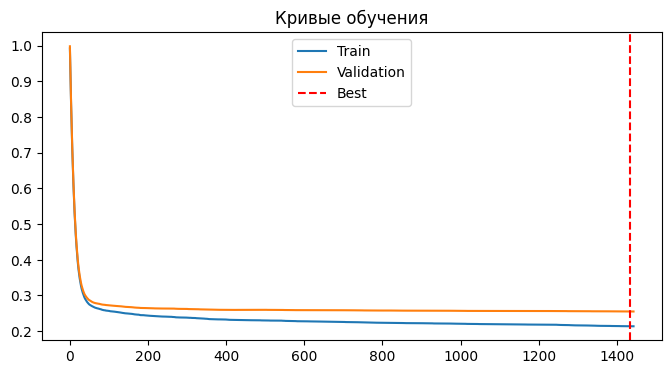

In [ ]:
# 3. КРИВЫЕ ОБУЧЕНИЯ (на одном фолде)

train_idx, val_idx = next(KFold(n_splits=5, shuffle=True, random_state=42).split(X_train))
X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

y_tr_log = np.log1p(y_tr)
y_val_log = np.log1p(y_val)

demo_model = CatBoostRegressor(
    **best_params,
    cat_features=cat_features_idx,
    verbose=False
)
demo_model.fit(X_tr, y_tr_log, eval_set=(X_val, y_val_log), use_best_model=True)

# График
train_loss = demo_model.evals_result_['learn']['RMSE']
val_loss = demo_model.evals_result_['validation']['RMSE']

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(train_loss, label='Train')
plt.plot(val_loss, label='Validation')
plt.axvline(np.argmin(val_loss), color='r', linestyle='--', label='Best')
plt.legend(); plt.title('Кривые обучения'); plt.show()

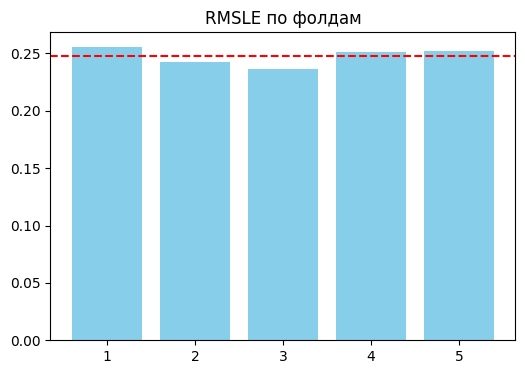

Среднее RMSLE (CV): 0.2478


In [ ]:
# 4. СТАБИЛЬНОСТЬ ПО ФОЛДАМ
# Гистограмма RMSLE по фолдам (стабильность CV)
cv_rmsle_per_fold = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    y_tr_log = np.log1p(y_tr)
    y_val_log = np.log1p(y_val)

    model = CatBoostRegressor(**best_params, cat_features=cat_features_idx, verbose=False)
    if USE_GPU:
        model.set_params(task_type='GPU', devices='0')
    model.fit(X_tr, y_tr_log, verbose=False)

    y_pred_fold_log = model.predict(X_val)
    fold_rmsle = np.sqrt(np.mean((y_val_log - y_pred_fold_log) ** 2))
    cv_rmsle_per_fold.append(fold_rmsle)

# Визуализация
plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), cv_rmsle_per_fold, color='skyblue')
plt.axhline(np.mean(cv_rmsle_per_fold), color='red', linestyle='--')
plt.title('RMSLE по фолдам'); plt.show()

print(f"Среднее RMSLE (CV): {np.mean(cv_rmsle_per_fold):.4f}")

In [ ]:
plt.figure(figsize=(5, 4))
plt.boxplot(cv_rmsle_per_fold, vert=False, patch_artist=True)
plt.xlabel('RMSLE')
plt.title('Распределение RMSLE по фолдам (5-Fold CV)')
plt.show()

print(f"Медиана RMSLE: {np.median(cv_rmsle_per_fold):.4f}")
print(f"Стандартное отклонение: {np.std(cv_rmsle_per_fold):.4f}")

In [ ]:
# Если позже вы захотите сравнить, например, две модели:
plt.boxplot([rmsle_model1, rmsle_model2], labels=['CatBoost v1', 'CatBoost v2'])

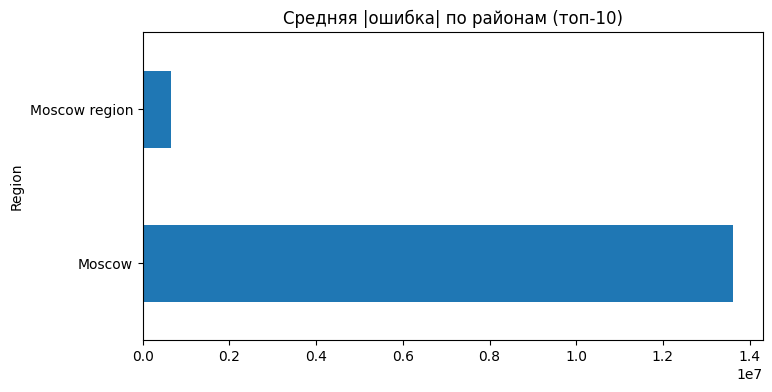


ТОП-5 худших предсказаний:
             y_true        y_pred     abs_error   Area  Region
907    5.169000e+08  1.293934e+09  7.770344e+08  861.5  Moscow
10312  1.362011e+09  6.363330e+08  7.256780e+08  584.1  Moscow
9066   9.631364e+08  4.865165e+08  4.766198e+08  443.8  Moscow
2966   6.853900e+08  2.465894e+08  4.388006e+08  229.3  Moscow
2878   5.575845e+08  2.100411e+08  3.475434e+08  359.5  Moscow


In [ ]:
# 5. АНАЛИЗ ОШИБОК НА X_test

df_analysis = X_test.copy()
df_analysis['y_true'] = y_test
df_analysis['y_pred'] = y_pred
df_analysis['abs_error'] = np.abs(y_pred - y_test)

# Пример: ошибки по району
plt.figure(figsize=(8, 4))
df_analysis.groupby('Region')['abs_error'].mean().nlargest(10).plot(kind='barh')
plt.title('Средняя |ошибка| по районам (топ-10)'); plt.show()

# ТОП-5 худших
print("\nТОП-5 худших предсказаний:")
print(df_analysis[['y_true', 'y_pred', 'abs_error', 'Area', 'Region']].sort_values('abs_error', ascending=False).head())

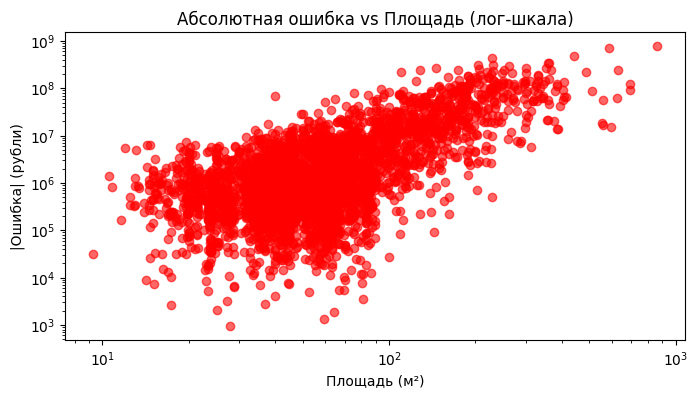

In [ ]:
# Ошибка vs Площадь (на X_test)
plt.figure(figsize=(8, 4))
plt.scatter(df_analysis['Area'], df_analysis['abs_error'], alpha=0.6, c='red')
plt.xlabel('Площадь (м²)')
plt.ylabel('|Ошибка| (рубли)')
plt.xscale('log')
plt.yscale('log')
plt.title('Абсолютная ошибка vs Площадь (лог-шкала)')
plt.show()

Абсолютная ошибка модели демонстрирует сильную положительную корреляцию с площадью: чем больше квартира, тем выше ошибка.   

Наибольшие ошибки сосредоточены в элитном сегменте (Москва, >400 м2), что свидетельствует о необходимости логарифмирования площади для стабилизации предсказаний на хвосте распределения.

In [ ]:
# РЕЗУЛЬТАТЫ: Лучшие гиперпараметры (без логарифмирования площадей)

BEST_PARAMS_BASELINE = {
    'iterations': 1444,
    'learning_rate': 0.06700723454135675,
    'depth': 8,
    'l2_leaf_reg': 3.540989799713105,
    'random_strength': 1.388779514324415,
    'bagging_temperature': 0.7491088608492634,
    'min_data_in_leaf': 4
}

print("Базовые гиперпараметры сохранены для воспроизводимости.")

In [ ]:
# После завершения текущей Optuna
best_params_v1 = study.best_params
rmsle_v1 = study.best_value

print(f"Baseline (без log(Area)): RMSLE = {rmsle_v1:.5f}")

##  ГРАФИК 2: Ошибки по категории (ремонт и тип жилья)


ТОП-5 худших предсказаний:
             y_true        y_pred     abs_error Renovation Apartment type
907    5.169000e+08  1.293934e+09  7.770344e+08   Designer      Secondary
10312  1.362011e+09  6.363330e+08  7.256780e+08   Designer      Secondary
9066   9.631364e+08  4.865165e+08  4.766198e+08   Designer      Secondary
2966   6.853900e+08  2.465894e+08  4.388006e+08   Designer      Secondary
2878   5.575845e+08  2.100411e+08  3.475434e+08   Designer      Secondary


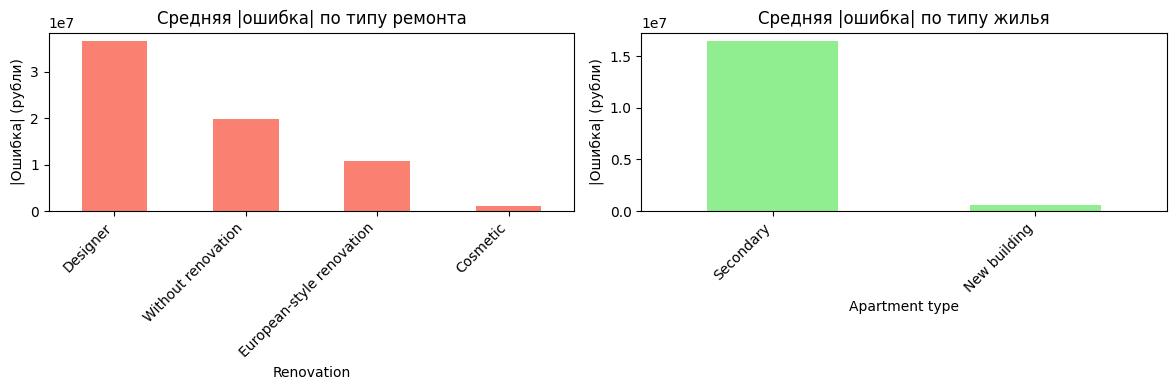

In [ ]:
# Готовим данные
df_analysis = X_test.copy()
df_analysis['y_true'] = y_test
df_analysis['y_pred'] = y_pred
df_analysis['abs_error'] = np.abs(y_pred - y_test)

print("\nТОП-5 худших предсказаний:")
print(df_analysis[['y_true', 'y_pred', 'abs_error', 'Renovation', 'Apartment type']]
      .sort_values('abs_error', ascending=False).head())

plt.figure(figsize=(12, 4))

# 1. По ремонту
plt.subplot(1, 2, 1)
renovation_error = df_analysis.groupby('Renovation')['abs_error'].mean().sort_values(ascending=False)
renovation_error.plot(kind='bar', color='salmon')
plt.title('Средняя |ошибка| по типу ремонта')
plt.ylabel('|Ошибка| (рубли)')
plt.xticks(rotation=45, ha='right')

# 2. По типу жилья
plt.subplot(1, 2, 2)
apt_type_error = df_analysis.groupby('Apartment type')['abs_error'].mean().sort_values(ascending=False)
apt_type_error.plot(kind='bar', color='lightgreen')
plt.title('Средняя |ошибка| по типу жилья')
plt.ylabel('|Ошибка| (рубли)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Модель хуже всего предсказывает вторичные квартиры с дизайнерским ремонтом — требуется улучшение представления элитного сегмента через трансформацию признаков.

## Обновите create_features_v2

In [ ]:
def create_features_v2(X):
    df = X.copy()

    # Исправление этажности
    mask_floor = df['Floor'] > df['Number of floors']
    df.loc[mask_floor, ['Floor', 'Number of floors']] = df.loc[mask_floor, ['Number of floors', 'Floor']].values

    # Обработка комнат
    df['is_studio'] = (df['Number of rooms'] == 0).astype(int)
    df['rare_big_flat'] = (df['Number of rooms'] >= 7).astype(int)
    df['rooms_capped'] = df['Number of rooms'].clip(upper=6)
    df = df.drop('Number of rooms', axis=1)

    # Логарифмирование площадей
    df['log_Area'] = np.log1p(df['Area'])
    df['log_Living area'] = np.log1p(df['Living area'])
    df['log_Kitchen area'] = np.log1p(df['Kitchen area'])

    # Удаляем исходные
    df = df.drop(['Area', 'Living area', 'Kitchen area'], axis=1)

    # Индикатор элитного жилья
    df['is_elite'] = (df['log_Area'] > np.log1p(200)).astype(int)  # >200 м²

    # Новые фичи
    df['kitchen_ratio'] = df['log_Kitchen area'] / df['log_Area']
    df['living_ratio'] = df['log_Living area'] / df['log_Area']

    renovation_map = {'Without renovation': 0, 'Cosmetic': 1, 'Euro': 2, 'Designer': 3}
    df['renovation_score'] = df['Renovation'].map(renovation_map).fillna(0)
    df['area_x_renovation'] = df['log_Area'] * df['renovation_score']

    df['apt_type_x_region'] = df['Apartment type'].astype(str) + '_' + df['Region'].astype(str)
    df['region_x_renovation'] = df['Region'].astype(str) + '_' + df['Renovation'].astype(str)

    df['is_new_building'] = (df['Apartment type'] == 'New building').astype(int)
    df['area_x_new_building'] = df['log_Area'] * df['is_new_building']

    df = df.drop('renovation_score', axis=1, errors='ignore')

    return df

In [ ]:
# Исходные данные
X_raw = df.drop('Price', axis=1)
y = df['Price']

# Новый split (тот же random_state!)
X_train_v2, X_test_v2, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# Применяем новую функцию
X_train_v2 = create_features_v2(X_train_v2)
X_test_v2 = create_features_v2(X_test_v2)

print(f"Новые данные: X_train_v2 {X_train_v2.shape}, X_test_v2 {X_test_v2.shape}")

Новые данные: X_train_v2 (16205, 20), X_test_v2 (4052, 20)


In [ ]:
categorical_features_v2 = [
    'Apartment type', 'Region', 'Renovation', 'metro_cluster',
    'apt_type_x_region', 'region_x_renovation'
]

cat_features_idx_v2 = [X_train_v2.columns.get_loc(col) for col in categorical_features_v2]

In [ ]:
import joblib

# Кросс-валидация
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def objective_v2(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 800, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.025, 0.07, log=True),
        'depth': trial.suggest_int('depth', 5, 7),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 2.5, 5.5),
        'random_strength': trial.suggest_float('random_strength', 0.9, 1.4),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.2, 0.7),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 4, 9),
        'verbose': False,
        'random_seed': 42
    }

    scores = []
    for train_idx, val_idx in kf.split(X_train_v2):
        X_tr, X_val = X_train_v2.iloc[train_idx], X_train_v2.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        y_tr_log = np.log1p(y_tr)
        y_val_log = np.log1p(y_val)

        model = CatBoostRegressor(**params, cat_features=cat_features_idx_v2)
        model.fit(
            X_tr, y_tr_log,
            eval_set=(X_val, y_val_log),
            early_stopping_rounds=40,
            use_best_model=True,
            verbose=False
        )
        y_pred_log = model.predict(X_val)
        score = np.sqrt(np.mean((y_val_log - y_pred_log) ** 2))
        scores.append(score)
    return np.mean(scores)

# Запуск
study_v2 = optuna.create_study(direction='minimize')
study_v2.optimize(objective_v2, n_trials=40)

# Финальный результат
print(f"\n RMSLE новой модели (с log_Area): {study_v2.best_value:.5f}")

[I 2025-11-28 16:58:26,779] A new study created in memory with name: no-name-79dd36ba-6c3e-4942-910f-e605629e6b3f
[I 2025-11-28 17:00:44,851] Trial 0 finished with value: 0.24192490779025907 and parameters: {'iterations': 1063, 'learning_rate': 0.049369717290939356, 'depth': 7, 'l2_leaf_reg': 3.536671735660823, 'random_strength': 1.107965546284987, 'bagging_temperature': 0.3403983305249889, 'min_data_in_leaf': 4}. Best is trial 0 with value: 0.24192490779025907.
[I 2025-11-28 17:02:55,051] Trial 1 finished with value: 0.24460505185435624 and parameters: {'iterations': 1272, 'learning_rate': 0.040605210934770576, 'depth': 6, 'l2_leaf_reg': 3.8263692154895583, 'random_strength': 1.0213136604828559, 'bagging_temperature': 0.6245614093059649, 'min_data_in_leaf': 9}. Best is trial 0 with value: 0.24192490779025907.
[I 2025-11-28 17:05:10,153] Trial 2 finished with value: 0.24256570165170394 and parameters: {'iterations': 1086, 'learning_rate': 0.04431339753942852, 'depth': 7, 'l2_leaf_reg':


 RMSLE новой модели (с log_Area): 0.23886
